## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 25.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/Advanced Machine Learning/Project-EasyVisa/EasyVisa.csv")

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
# Create a copy of the data
df = data.copy()

In [ ]:
# View first 5 rows
df.head()


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
# View last 5 rows
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
# Checking the number of rows and columns in the data
df.shape

(25480, 12)

* There are 25480 rows and 12 columns in the given dataset.



#### Check the data types of the columns for the dataset

In [ ]:
# Checking the data tupes of the columns in the given dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* Only 3 variables are numerical(2 integer & 1 float) and rest all are of object types.
* All columns have equal number of non-null values(25480) - indicates there are no missing values.

In [ ]:
# Checking for duplicate values in the data
df.duplicated().sum()


np.int64(0)

* There are no duplicate values in the given dataset.

In [ ]:
# Checking for missing values
round(df.isnull().sum() / df.isnull().count() * 100, 2)

,0
case_id,0.000
continent,0.000
education_of_employee,0.000
has_job_experience,0.000
requires_job_training,0.000
no_of_employees,0.000
yr_of_estab,0.000
region_of_employment,0.000
prevailing_wage,0.000
unit_of_wage,0.000


* There are no missing values in the given dataset.

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
# Checking statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


# Observations on numerical columns

## no_of_employees
* no_of_employees across employers range from -26(which does not seem appropriate) to a max of 602069. The negative count(-26) clearly indicates an invalid entry and needs to be treated.
* The median(50% percentile) number of employees is 2109, indicate half of the employers have about 2109 employees.
* One of the employer has a max of 602069 employees indicating a large organization, likely an outlier compared to other majority of employers in the given dataset.
* Negative values and outliers need to be treated/cleaned where required.

## yr_of_estab
* One company(of the employer) seem to be establised way back in the year 1800 and to the latest one being established in the year 2016.
* Employer established in the year 1800 seems a little unrealistic to be still active, but remotely may be possible.
* 25% of companies got established in the year 1976, 50% in 1997 and 75% in 2005.
* This data indicates a mix of both long-standing companies to the latest organizations as latest as 2016.

## prevailing_wage
* Average prevailing_wage is $74455.815. This seems to be yearly income for most job positions.


* The min prevailing_wage of $2.137 seems to be an hourly wage rate in some area of work. This wage looks too low as per the standard minimum wage rate in the USA. But, it depends on the area of work & place of work. This indicates there are some jobs(in the dataset) which represent hourly wage positions.

* The standard U.S. federal minimum wage is 7.25 per hour (set in 2009), and a rate of 2.13 per hour is the minimum cash wage for tipped employees, but their total earnings (direct wage plus tips) must equal at least the federal or state minimum wage, whichever is higher. Jobs with a 2.13 hourly rate typically involve food service, like waitstaff, bartenders, and bussers, and any other jobs where employees customarily and regularly receive more than $30 per month in tips (As per Google).


* 50% of job positions have atleast $70308.210 wage (which seems to be yearly salary).

* 75% have around 107K(yearly) & some position has a max wage of 319210.270 indicating a very specialized or executive-level position.

* prevailing_wage data seems to be right skewed with a few highly paid jobs increasing the average.




In [ ]:
# Checking statistical summary of categorical columns
df.describe(include="O").T

,count,unique,top,freq
case_id,25480,25480,EZYV25480,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


## Observations on categorical columns

* case_id being a unique identifier doesn't add any meaning to the analysis and can be dropped.
* The dataset includes applicants from 6 different continents with the majority from Asia(16861 applicants) indicating significant portion of visa applications originating from Asian countries.
* The applicants seem to be possesing one of the four education degrees, with most(10234) holding a Bachelor's degree. This indicates a well-qualified applicant pool.
* 14802 applicants have prior job experience. This indicates rest of the applicants might be first-time/entry level job applicants.
* 22525 applicants do not require job training, indicating that most applicants are already skilled or trained for their respective positions.
* Applicants have applied across 5 US regions, with the NORTHEAST region having the highest number of applicants(7195). This could reflect either regional demand or concentraion of sponsoring employers there.
* unit_of_wage - there are four wage types - Hourly, Weekly, Monthly and Yearly paid jobs, with majority(90%) being Yearly paid positions(22962). This also indicates most applications are for salaried jobs rather than hourly or contractual roles.
* Approximately 89.3% of the jobs applied are for full time position, indicating most employers are hiring for permanent or long-term roles.
* case_status which is the target variable in this project, indicates that 66.78%(17018) of the applications have been Certified, rest denied.


### Conclusion
The categorical summary reveals that most applicants are experienced, well-educated, and apply for full-time, yearly-paid roles in the U.S., primarily from Asian countries. This demographic and job-type concentration could be key factors influencing visa approval outcomes.


#### Fixing the negative values in number of employees columns

In [ ]:
# Check how many records have negative employee counts
(df["no_of_employees"] < 0).sum()


np.int64(33)

In [ ]:
# View those records
df[df["no_of_employees"] < 0]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.990,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.140,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.940,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.460,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.970,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.320,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.950,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.500,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.610,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.510,Year,Y,Certified


In [ ]:
# These seem to be data entry errors. So, let's replace them with absolute values
df["no_of_employees"] = df["no_of_employees"].abs()

In [ ]:
# Check how many records have negative employee counts, if any after absoluting them.
(df["no_of_employees"] < 0).sum()

np.int64(0)

In [ ]:
# let's check statistical summary again
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.089,22877.917,11.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


## Observations
* Earlier to replacing the records with negative no_of_employees (-26) with their absolute valies, the min no_of_employees was -26.
* Now after the treatment, it is 11.00.

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# list of all categorical variables
cat_col = df.columns

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

case_id
EZYV25480   0.000
EZYV01      0.000
EZYV02      0.000
EZYV03      0.000
EZYV04      0.000
             ... 
EZYV13      0.000
EZYV12      0.000
EZYV11      0.000
EZYV10      0.000
EZYV09      0.000
Name: proportion, Length: 25480, dtype: float64
--------------------------------------------------
continent
Asia            0.662
Europe          0.146
North America   0.129
South America   0.033
Africa          0.022
Oceania         0.008
Name: proportion, dtype: float64
--------------------------------------------------
education_of_employee
Bachelor's    0.402
Master's      0.378
High School   0.134
Doctorate     0.086
Name: proportion, dtype: float64
--------------------------------------------------
has_job_experience
Y   0.581
N   0.419
Name: proportion, dtype: float64
--------------------------------------------------
requires_job_training
N   0.884
Y   0.116
Name: proportion, dtype: float64
--------------------------------------------------
no_of_employees
183     0.001
854 

## Observations
* case_id - being a unique identifier doesn't add any meaning to the analysis and can be dropped.
* continent — Applicants come from 6 continents, with the majority from Asia (66.2%), followed by Europe (14.6%) and North America (12.9%). The remaining continents — South America (3.3%), Africa (2.2%), and Oceania (0.8%) — contribute very few applicants. Indicates that most visa applications are filed by Asian candidates.
* education_of_employee — The most common education level is Bachelor’s (40.2%), followed closely by Master’s (37.8%). High School graduates (13.4%) and Doctorate holders (8.6%) form the minority. Suggests that the applicant pool is generally well-educated, with a strong concentration in undergraduate and postgraduate degrees.
* has_job_experience — About 58.1% of applicants have prior job experience, while 41.9% do not. A significant portion of applicants are experienced professionals, but there is also a considerable share of first-time job seekers.
* requires_job_training — Only 11.6% of applicants require job training, while 88.4% do not. Indicates that most applicants already possess the required skills or training for their roles.
* no_of_employees — The employer sizes vary widely, with no single organization dominating the dataset. The most frequent counts are around 183, 854, and 724 employees, but proportions are very small. Suggests the dataset includes a broad mix of small, medium, and large companies.
* yr_of_estab — The most common establishment years are 1998 (4.5%), 2005 (4.1%), 2001 (4.0%), 2007 (3.9%), and 1999 (3.4%). Implies that a large share of employers were founded in the late 1990s to early 2000s.
* region_of_employment — Applications are spread across 5 U.S. regions. The Northeast (28.2%), South (27.5%), and West (25.8%) dominate, while the Midwest (16.9%) and Island territories (1.5%) have fewer applications.
* prevailing_wage — prevailing_wage data seems to be right skewed with a few highly paid jobs increasing the average.
* unit_of_wage — The majority (90.1%) of wages are paid yearly, followed by hourly (8.5%), weekly (1.1%), and monthly (0.3%). Suggests most applicants are applying for salaried (annual) positions.
* full_time_position — 89.4% of positions are full-time, and 10.6% are part-time. Reinforces that the dataset mainly covers permanent or long-term employment roles.
* case_status — The target variable, showing 66.8% Certified (approved) and 33.2% Denied applications. Indicates a moderate class imbalance, but not extreme — can be handled effectively using resampling methods like SMOTE during model training.

In [ ]:
# case_id is unique for each candidate and might not add value to modeling
df.drop(["case_id"], axis=1, inplace=True)

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Observations on education of employee

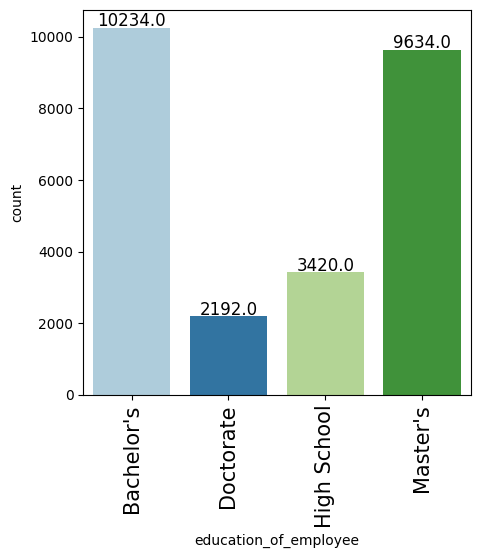

In [ ]:
# education_of_employee is a categorical column, hence going for barplot

labeled_barplot(df, "education_of_employee")

## Observations - education_of_employee
 * The most common education level is Bachelor’s (40.2%), followed closely by Master’s (37.8%). High School graduates (13.4%) and Doctorate holders (8.6%) form the minority. Suggests that the applicant pool is generally well-educated, with a strong concentration in undergraduate and postgraduate degrees.
 * This also indicates atleast 78% (40.2 + 37.8) of the applications have atleast a bachelor's degree.

#### Observations on region of employment

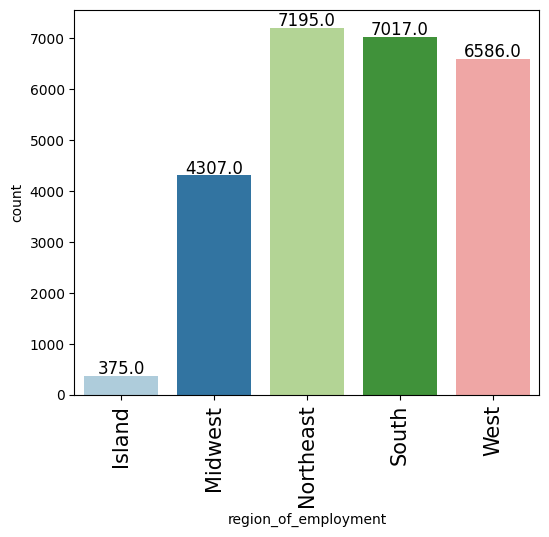

In [ ]:
# region_of_employment is a categorical column, hence going for barplot

labeled_barplot(df, "region_of_employment")

## Observations - region_of_employment

* Applications are spread across 5 U.S. regions. The Northeast (28.2%), South (27.5%), and West (25.8%) dominate, while the Midwest (16.9%) and Island territories (1.5%) have fewer applications.

* NORTHEAST region having the highest number of applicants(7195).

* This could reflect either regional demand or concentraion of sponsoring employers there.

#### Observations on job experience

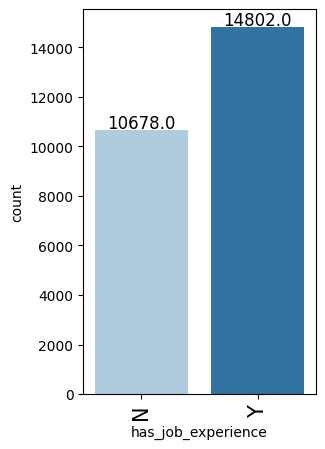

In [ ]:
# has_job_experience is a categorical column, hence going for barplot

labeled_barplot(df, "has_job_experience")

## Observations - has_job_experience

* About 58.1%(14802) of applicants have prior job experience, while 41.9% do not.
* This indicates rest of the applicants might be first-time/entry level job applicants.

#### Observations on case status

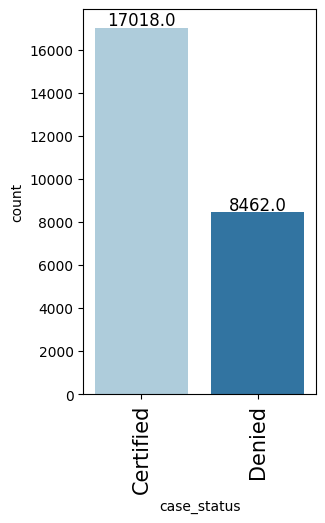

In [ ]:
# case_status which is the target variable, is a categorical variable too. Hence, going for barplot.

labeled_barplot(df, "case_status")

## Observations - case_status

* case_status which is the target variable in this project, indicates that 66.78%(17018) of the applications have been Certified, rest 33.2% (8462) denied.
* Indicates a moderate class imbalance, but not extreme — can be handled effectively using resampling methods like SMOTE during model training.


## Univariate Analysis of remaining Categorical variables



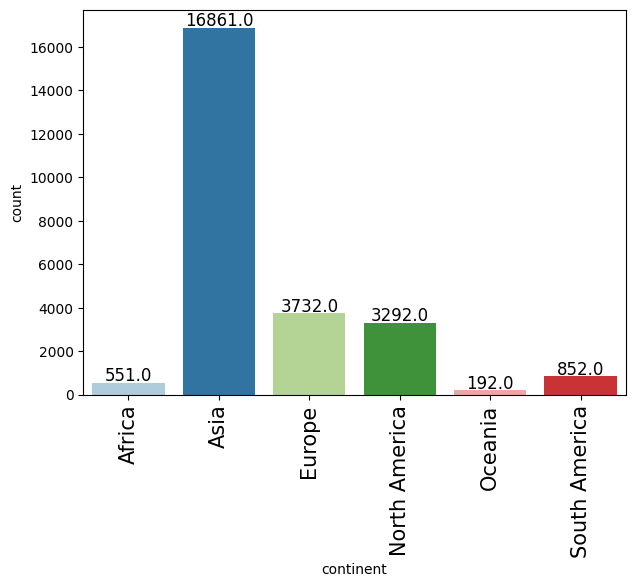

In [ ]:
# continent is a categorical variable, hence going for barplot

labeled_barplot(df, "continent")

## Observations - continent

* Applicants come from 6 continents, with the majority from Asia (66.2%), followed by Europe (14.6%) and North America (12.9%).
* The remaining continents — South America (3.3%), Africa (2.2%), and Oceania (0.8%) — contribute very few applicants.
* Indicates that most visa applications are filed by Asian candidates.

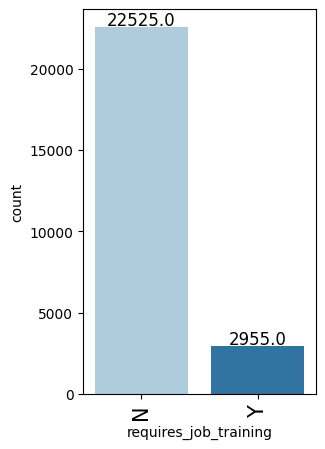

In [ ]:
# requires_job_training is a categorical variable, hence going for barplot

labeled_barplot(df, "requires_job_training")

## Observations - requires_job_training

* Only 11.6% (2955) of applicants require job training, while 88.4%(22525) do not.
* Indicates that most applicants already possess the required skills or training for their roles.

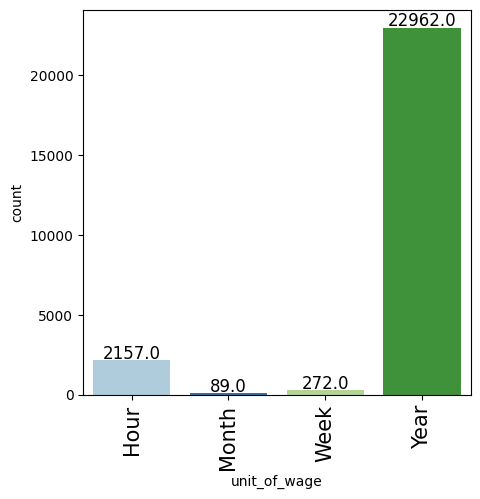

In [ ]:
# unit_of_wage is a categorical variable, hence going for barplot

labeled_barplot(df, "unit_of_wage")

## Observations - unit_of_wage

* The majority (90.1%) of wages are paid yearly, followed by hourly (8.5%), weekly (1.1%), and monthly (0.3%).
* Suggests most applicants are applying for salaried (annual) positions

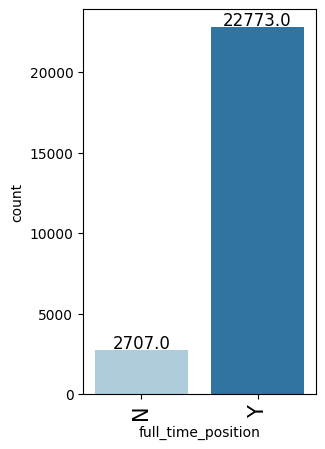

In [ ]:
# full_time_position is a categorical variable, hence going for barplot

labeled_barplot(df, "full_time_position")

## Observations - full_time_position

* 89.4% (22773) of positions are full-time, and 10.6% (2707) are part-time.
* Reinforces that the dataset mainly covers permanent or long-term employment roles.

## Univariate Analysis of Numerical Variables

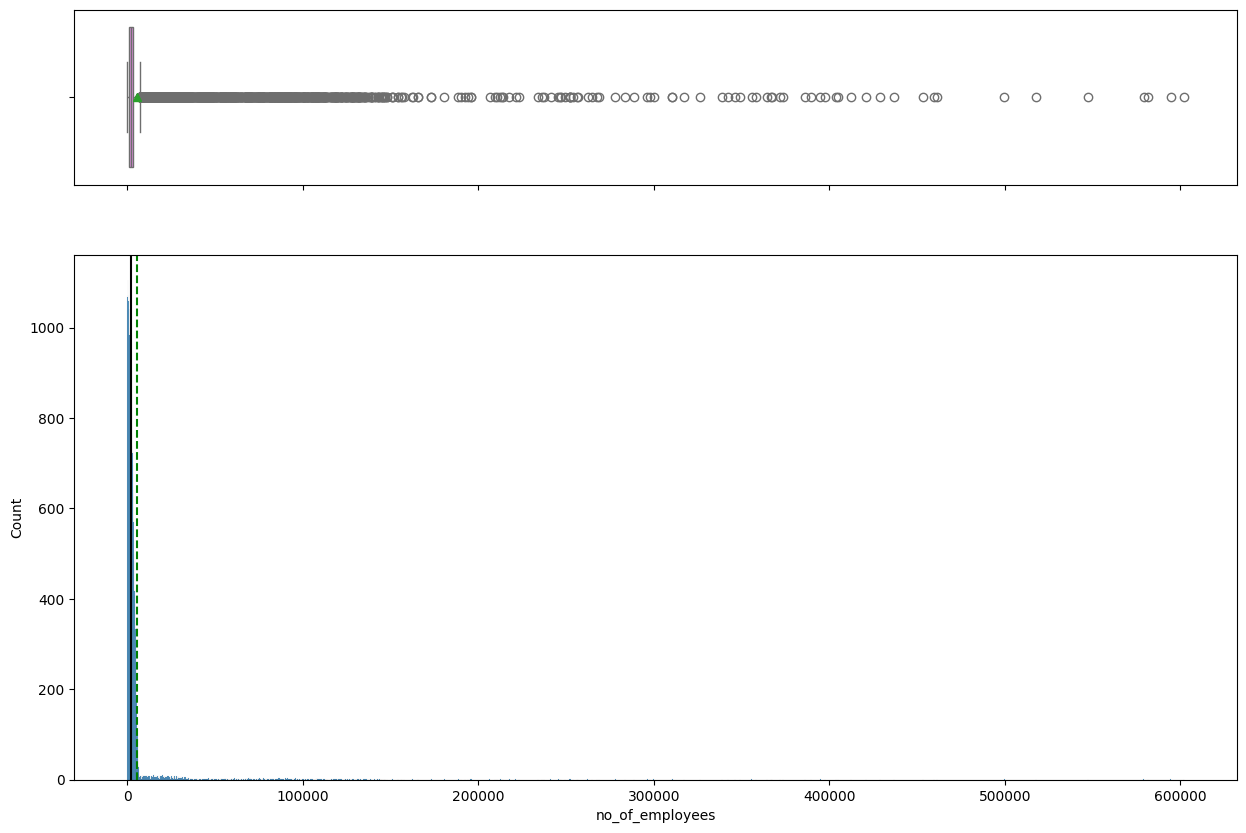

In [ ]:
# no_of_employees is a numerical variable, hence going for histogram + box plots

histogram_boxplot(df, "no_of_employees")

## Observations - no_of_employees

* The distribution is highly right-skewed (positively skewed) — most employers have small workforce sizes, while a few very large companies have extremely high employee counts (up to 600,000).

* The median number of employees is around 2,100, showing that half of the employers have fewer than ~2K employees.

* The boxplot indicates a large number of outliers on the higher end, representing very large corporations or potential data anomalies.

* Some entries also show negative employee values (as found during data inspection), which are invalid and should be corrected or removed.

* The majority of companies are small to mid-sized organizations, while only a few represent large-scale enterprises.

Conclusions:

* The variable no_of_employees has a right-skewed distribution, dominated by smaller organizations.

* Extreme outliers and negative values should be handled during data cleaning.



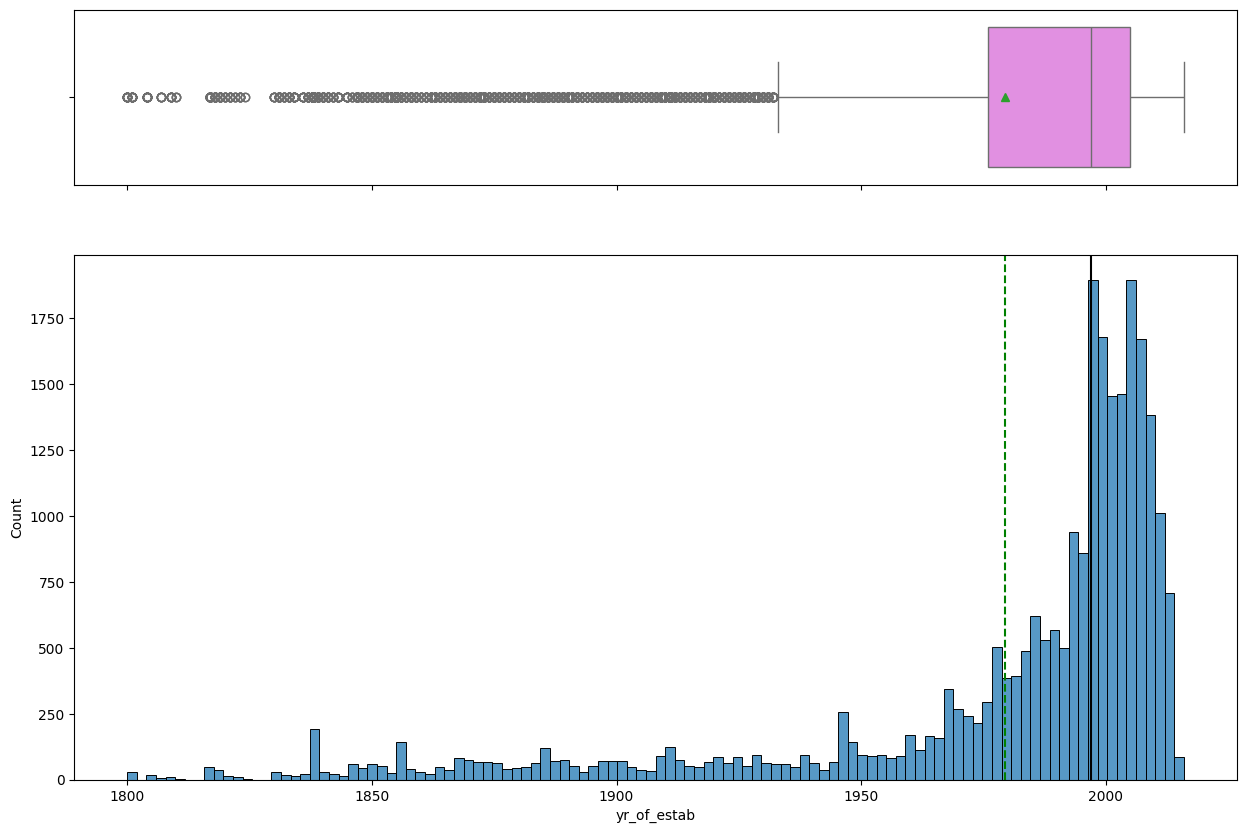

In [ ]:
# yr_of_estab is a numberical variable, hence going for histogram + boxplot

histogram_boxplot(df, "yr_of_estab")

## Observations - yr_of_estab


* The distribution is left-skewed (negatively skewed) — most companies were established in recent decades.

* Sharp rise in company establishments after 1950, peaking between 1990 and 2010.

* The median establishment year is around 1997.

* The boxplot shows many outliers on the lower end (before 1900), indicating invalid or legacy data entries.

* The majority of employers are modern organizations founded in the late 20th century.

Conclusions:

* yr_of_estab has a left-skewed distribution with a long tail toward older years.

* Most employers are relatively new, reflecting recent economic and industrial growth.

* Values before 1900 should be reviewed or removed to handle outliers and ensure data accuracy.

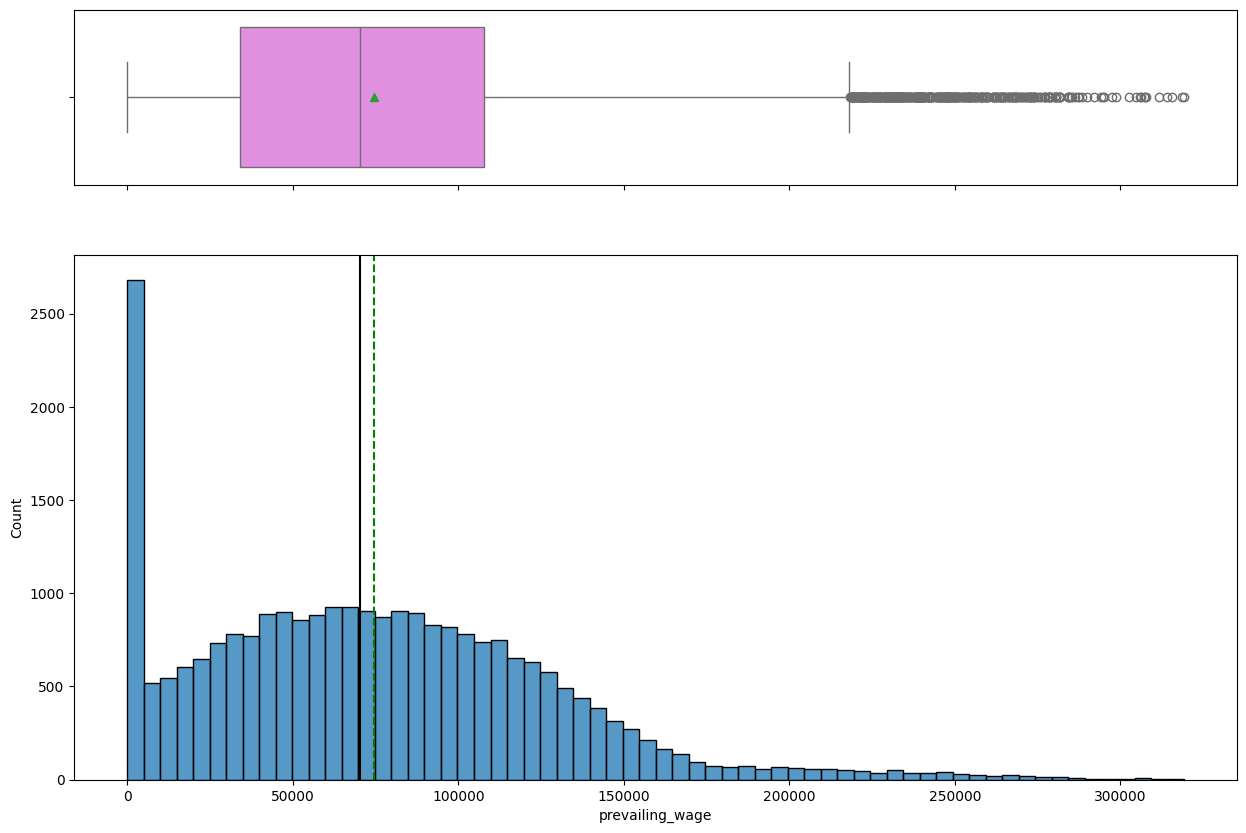

In [ ]:
# prevailing_wage is a numerical variable, hence going for histogram + boxplot

histogram_boxplot(df, "prevailing_wage")

## Observations

* The distribution is right-skewed (positively skewed) — most wages are on the lower end, with a long tail toward higher values.

* The median prevailing wage is around 70K, while a few positions exceed 300K, creating extreme outliers.

* A noticeable spike appears near very low wages (<$5K), likely due to hourly or tipped positions or data-entry errors.

* The boxplot shows several high-value outliers, indicating a few specialized or executive-level jobs with unusually high salaries.

* Most job roles fall within the $35K–$110K range, suggesting that the dataset primarily consists of mid-income professional positions.

Conclusions:

* The variable prevailing_wage has a right-skewed distribution, meaning most applicants earn moderate wages, while a small number earn extremely high salaries.

* Outliers on the higher side should be handled (e.g., capping or log transformation) before modeling to reduce skewness.

* The data suggests a wide income disparity among applicants, likely due to differing roles, regions, and experience levels.

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

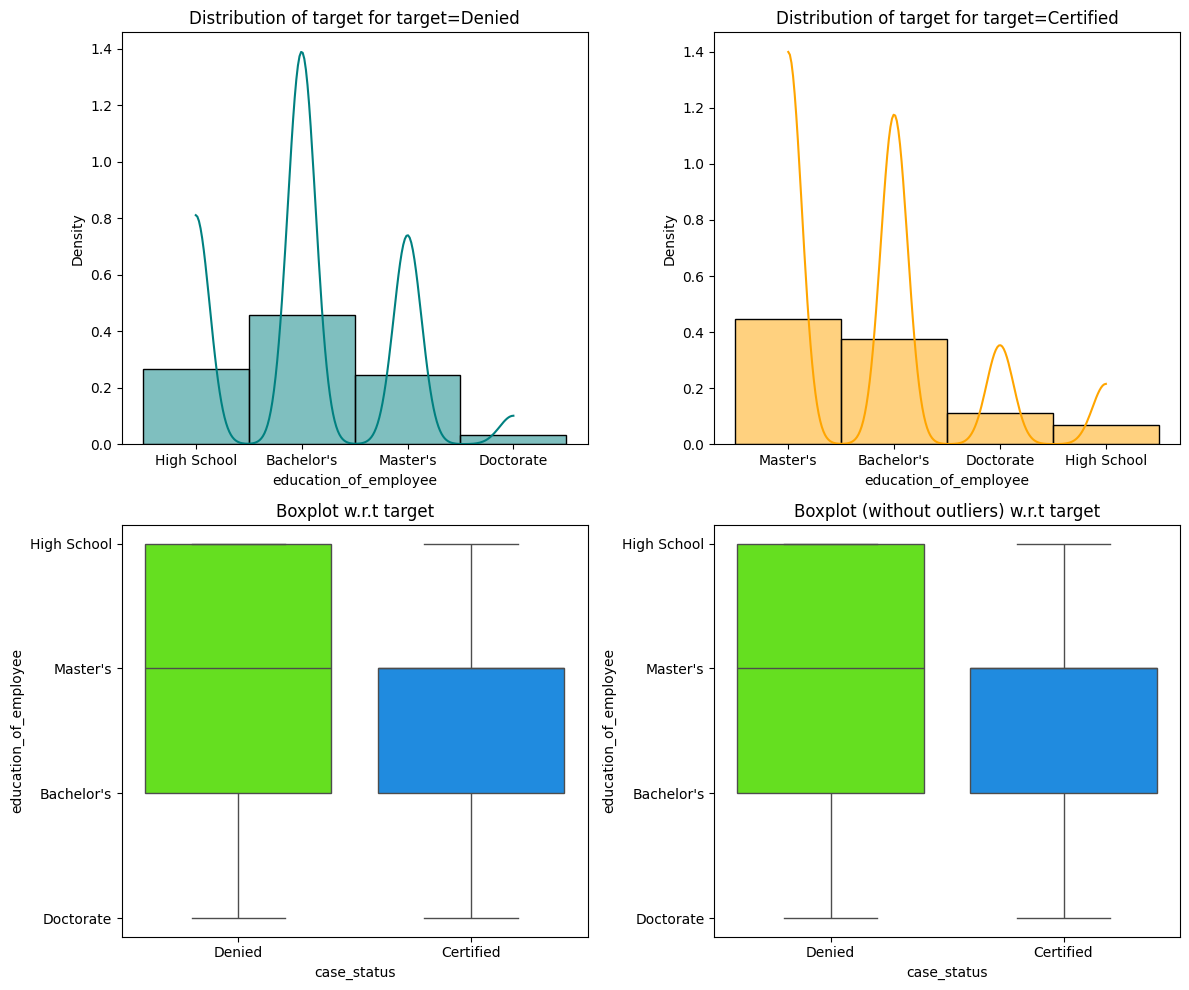

In [ ]:
# Does higher education increase the chances of visa certification for well-paid jobs abroad?

distribution_plot_wrt_target(df, "education_of_employee", "case_status")

## Observations

* The plots compare education levels (High School, Bachelor’s, Master’s, Doctorate) with the visa case outcome (Certified vs Denied).

* Applicants with Bachelor’s and Master’s degrees dominate the dataset for both certified and denied cases.

* The density for Certified cases peaks around Master’s and Bachelor’s degrees, indicating that applicants with these education levels have higher chances of visa approval.

* High School and Doctorate applicants form smaller proportions in both categories.

* High School: relatively fewer approvals, possibly due to limited skill or qualification match.

* Doctorate: small applicant group, likely niche roles, but approval rate appears moderate.

* The boxplots show that Certified cases generally correspond to higher education levels, while Denied cases have a slightly broader spread across lower education categories.

Conclusions:

* Higher education levels (especially Master’s and Bachelor’s) are positively correlated with visa certification.

* Applicants with lower education (High School) face higher chances of denial, possibly due to stricter qualification requirements for skilled roles.

* This trend suggests that education is a significant driver in visa approval outcomes for skilled jobs abroad.

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


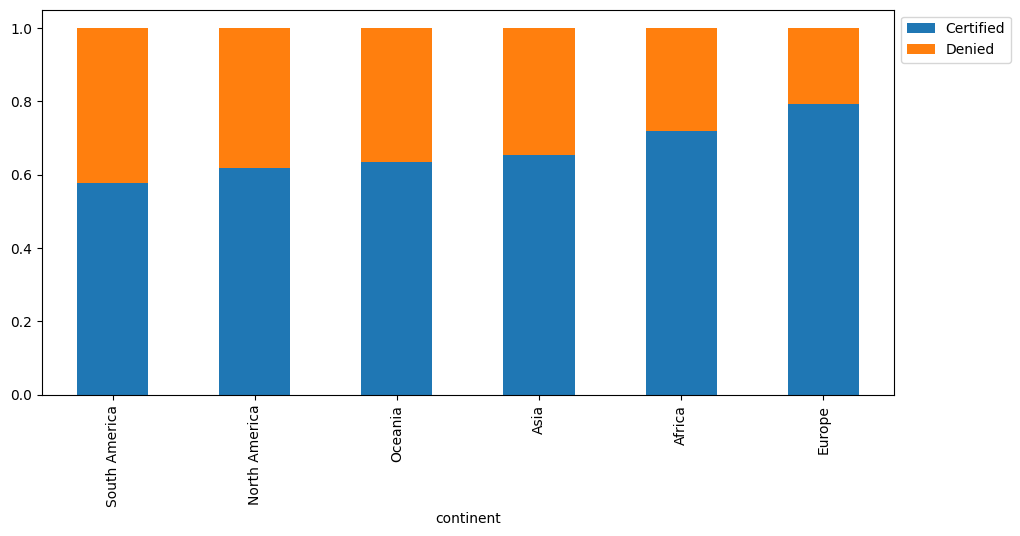

In [ ]:
# How does visa status vary across different continents?

stacked_barplot(df, "continent", "case_status")

## Observations

* The dataset includes visa applications from six continents — Asia, Europe, North America, South America, Africa, and Oceania.

* Asia contributes the highest number of applications (16,861), followed by North America (3,292) and Europe (3,732).

* Across all continents, Certified (Approved) cases outnumber Denied ones, reflecting an overall approval trend.

* Europe shows the highest visa approval rate (~79%), indicating strong employer compliance and skilled applicant profiles.

* Africa and Asia also show relatively high approval rates (~70–65%), while South America has the lowest success rate (~58%), with nearly 4 in 10 applications denied.

* Oceania and North America display moderate approval rates (~63–65%).

Conclusions:

* Visa certification rates vary by continent, with Europe having the most favorable outcome and South America the least.

* The overall approval rate is consistent across regions, but differences may stem from applicant qualifications, employer practices, or demand for specific job categories.

* This analysis suggests that regional economic or policy factors may influence visa certification outcomes.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


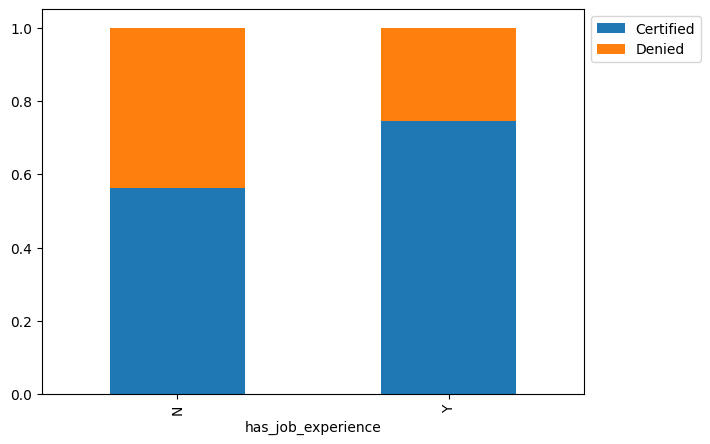

In [ ]:
# Does having prior work experience influence the chances of visa certification for career opportunities abroad?

# distribution_plot_wrt_target(df, "has_job_experience", "case_status")

stacked_barplot(df, "has_job_experience", "case_status")

## Observations

* The dataset divides applicants into two groups — those with prior job experience (Y) and those without experience (N).

* Out of 25,480 total applications,

    * 14,802 (≈58%) applicants have prior work experience, and

    * 10,678 (≈42%) do not.

* *Among experienced applicants (Y):

    * 11,024 were Certified, and 3,778 were Denied, indicating an approval rate of ~74%.

* Among non-experienced applicants (N):

    * 5,994 were Certified, and 4,684 were Denied, giving an approval rate of ~56%.

*  The stacked bar chart clearly shows that visa certification is significantly higher for candidates with prior job experience.

Conclusions:

* Applicants with prior work experience are more likely to get their visas certified than those without experience.

* Work experience likely serves as a strong indicator of job readiness and skill alignment, increasing the employer’s and immigration authority’s confidence in the application.

* This makes “has_job_experience” a key predictive variable for visa approval in future modeling.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


#### Is the prevailing wage consistent across all regions of the US?

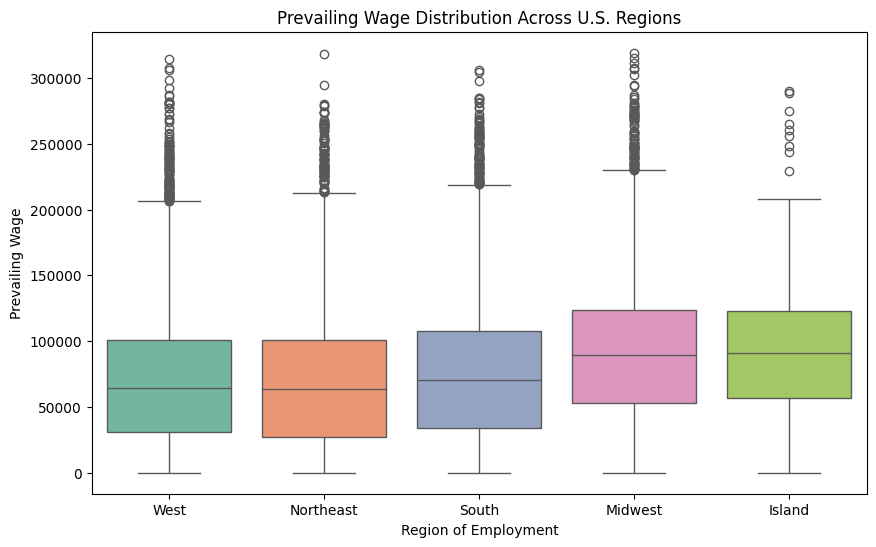

In [ ]:
# Is the prevailing wage consistent across all regions of the US?

plt.figure(figsize=(10,6))
sns.boxplot(x='region_of_employment', y='prevailing_wage', data=df, palette='Set2')
plt.title('Prevailing Wage Distribution Across U.S. Regions')
plt.xlabel('Region of Employment')
plt.ylabel('Prevailing Wage')
plt.show()

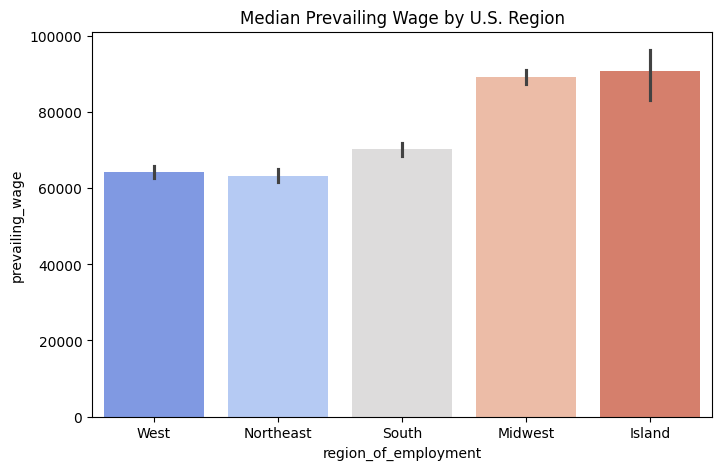

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='region_of_employment', y='prevailing_wage', data=df, estimator=np.median, palette='coolwarm')
plt.title('Median Prevailing Wage by U.S. Region')
plt.show()

## Observations

* Both boxplot and barplot analyses indicate that prevailing wages vary significantly across U.S. regions, showing that wage levels are not consistent nationwide.

* From the boxplot, the Midwest and Island regions display higher median wages and a broader wage range, suggesting stronger compensation levels and diversity in job types.

* The West and Northeast regions exhibit lower median wages (60K - 65K), even though both have a large number of high-end outliers — indicating that while a few positions pay very high salaries, most jobs are clustered in the lower range.

* The South region has a moderate median (70K), falling between the high-paying and lower-paying regions.

* The Island region has high variability, possibly due to location-based labor demands and specialized industries.

* The barplot (using median wages) reinforces these patterns — with Midwest and Island regions standing out with median wages near $90K, followed by South (70K), and West/Northeast trailing behind (65K).

* All regions show a wide interquartile range (IQR) and numerous outliers, suggesting that while the median differs, wage variability within each region is also high.

Conclusions

* Prevailing wage is not consistent across U.S. regions. There are clear regional disparities in compensation levels.

* Midwest and Island regions consistently offer higher median wages, while West and Northeast regions tend to have lower median wages on average.

* These differences may be influenced by regional economic conditions, industry concentration, and cost of living variations.

* From a modeling perspective, region_of_employment is a significant feature that should be included in predicting visa certification outcomes — as regions with higher wages may correlate with stronger job offers and higher chances of visa approval.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

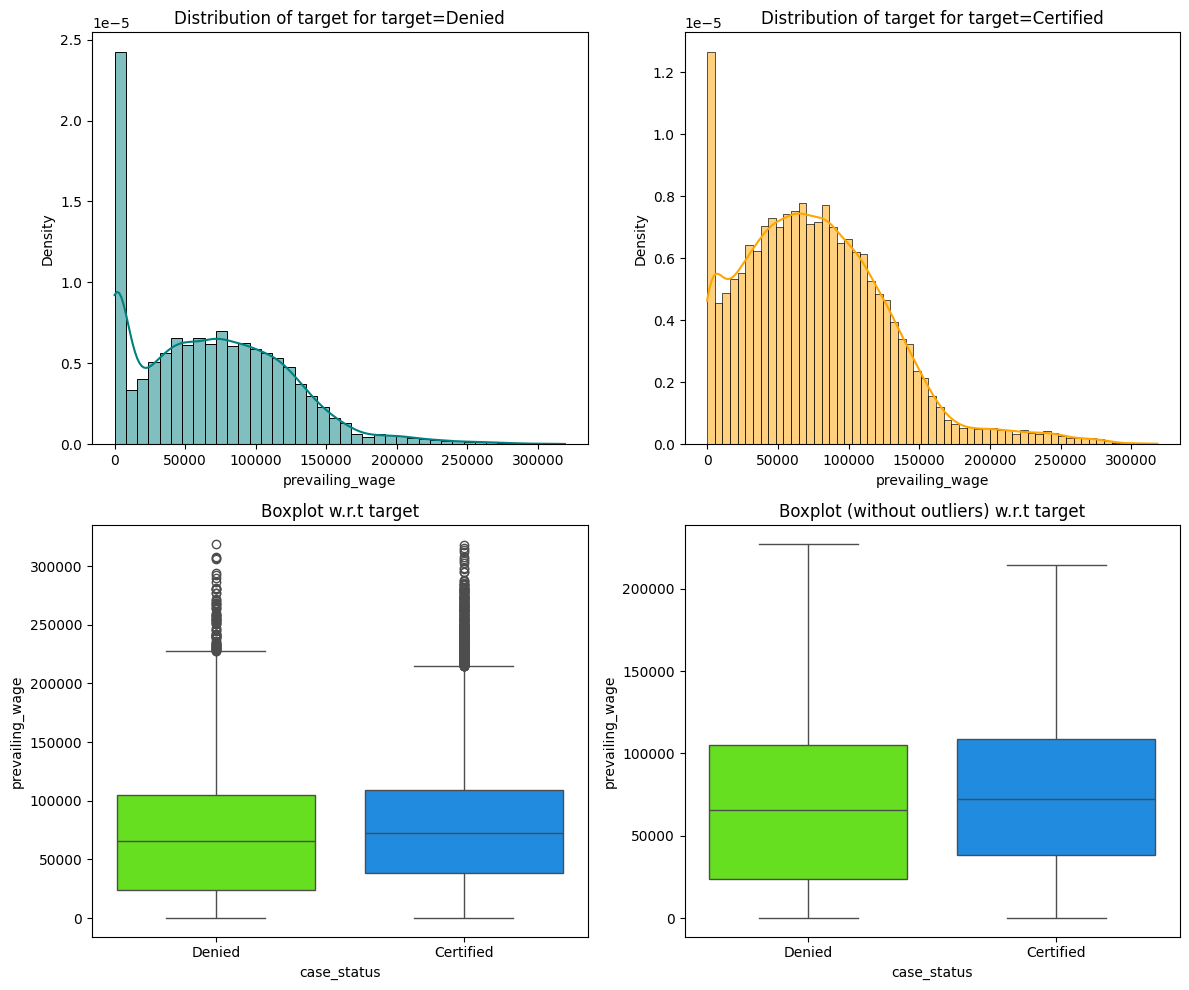

In [ ]:
# Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

## Observations

* Applicants with higher offered wages have a better chance of getting their visa approved (Certified).

* Most Denied applications are linked to lower-paying jobs (below $60K), while Certified ones fall mostly between 60K and 120K.

* The median and average wage for Certified cases are both higher than those for Denied cases.

* A few very high-paying jobs ($200K-$300K+) exist, and nearly all of them are Certified, not Denied.

* Even after removing extreme values (outliers), the same pattern holds — higher wages lead to more approvals.

Conclusions:

* Yes, visa status clearly depends on the prevailing wage.

* Higher wages indicate higher chances of visa approval, while low-paying offers are more likely to be rejected.

* This supports the goal of the prevailing wage policy — to ensure foreign workers are not underpaid and local job markets remain fair.

* In short, the better the pay, the better the visa approval odds.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


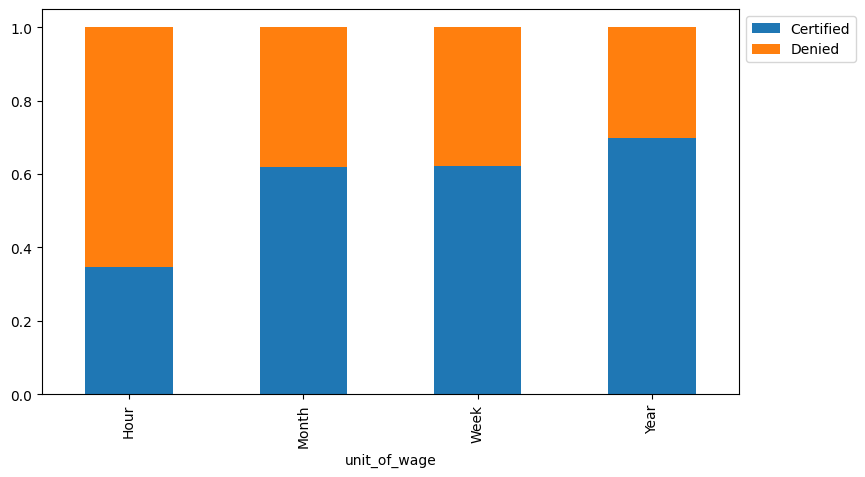

In [ ]:
# Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

stacked_barplot(df, "unit_of_wage", "case_status")

## Observations

* Most jobs in the dataset are yearly-paid positions (around 90% of total applications).

* Yearly-paid jobs have the highest visa approval rate — about 70% Certified and 30% Denied.

* Hourly-paid jobs have the lowest approval rate — only around 35% Certified, while about 65% are Denied.

* Weekly and Monthly jobs show moderate approval rates, but their sample sizes are quite small compared to yearly jobs.

* This pattern suggests that higher-paying and long-term employment types (yearly) are more likely to get approved, whereas hourly or short-term jobs are more likely to be denied.

Conclusions:

* Yes, the unit of wage affects visa approval chances.

* Yearly-paying jobs are much more likely to result in visa certification, while hourly jobs often get rejected.

* This makes sense — yearly salaries usually represent stable, skilled, full-time positions, while hourly roles may be seen as temporary or low-skill.

* In short, this indicates that full-time, long-term jobs with yearly salaries are far more likely to get visa approval than hourly or short-term jobs.

## Bivariate Analysis of Rest of the Variables

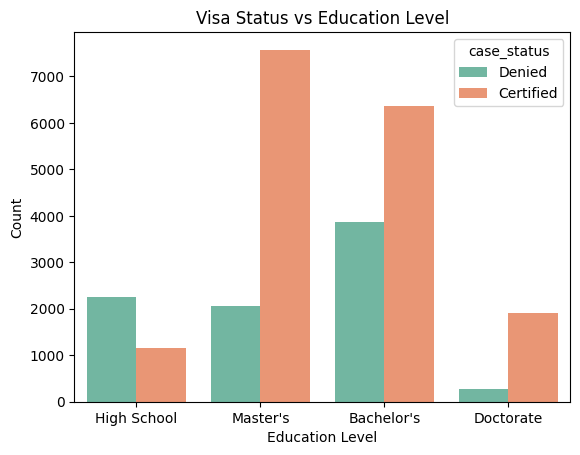

In [ ]:
# education_of_employee vs case_status
sns.countplot(x='education_of_employee', hue='case_status', data=df, palette='Set2')
plt.title("Visa Status vs Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

## Observations/Conclusions:

* Applicants with higher education levels (Master's, Bachelor's or Doctorate) have a higher visa certification rate.

* Those with only a High-School (or Bachelor's degree too) face more denials.

* Education appears to be a strong positive factor influencing visa approval.

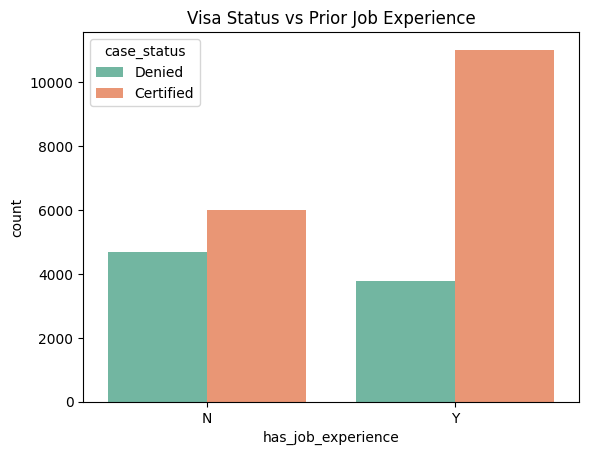

In [ ]:
# has_job_experience vs case_status

sns.countplot(x='has_job_experience', hue='case_status', data=df, palette='Set2')
plt.title("Visa Status vs Prior Job Experience")
plt.show()

## Observations/Conclusions:

* Applicants with prior work experience (Y) show a much higher proportion of certified cases.

* Applicants without experience (N) have a larger share of denials.

* Hence, job experience strongly improves the chance of certification.

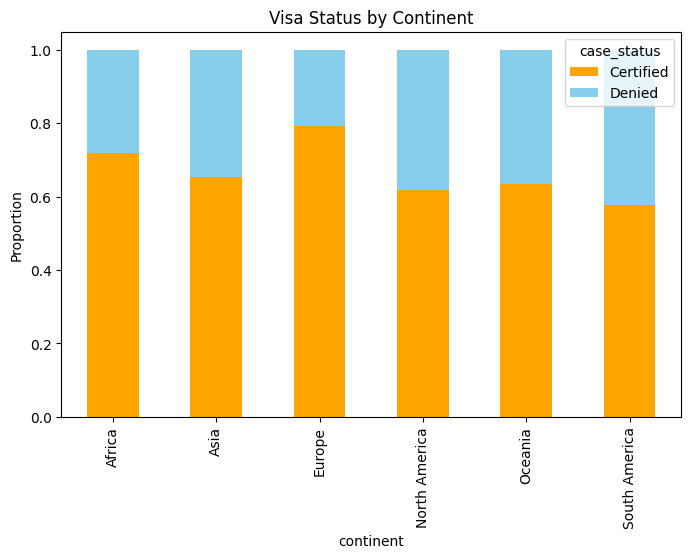

In [ ]:
# continent vs case_status

pd.crosstab(df['continent'], df['case_status'], normalize='index').plot(
    kind='bar', stacked=True, color=['orange', 'skyblue'], figsize=(8,5)
)
plt.title("Visa Status by Continent")
plt.ylabel("Proportion")
plt.show()

## Observations/Conclusions:

* Applicants from Asia form the largest group and also have the highest count of certified visas overall.

* However, the approval rate (proportion certified) is relatively higher for Europe and Africa.

* Regional differences indicate geographical influence in certification trends.

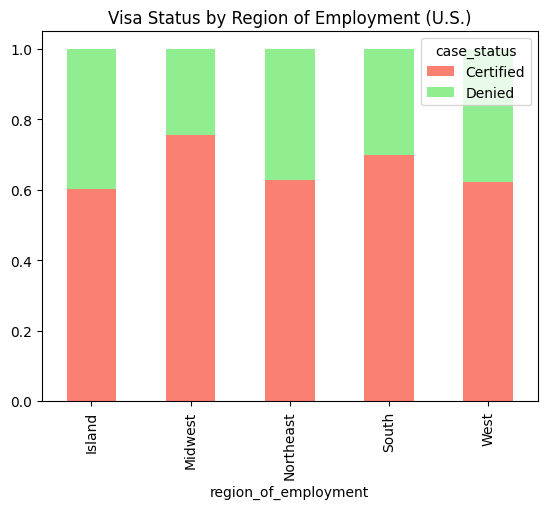

In [ ]:
# region_of_employment vs case_status

pd.crosstab(df['region_of_employment'], df['case_status'], normalize='index').plot(
    kind='bar', stacked=True, color=['salmon', 'lightgreen']
)
plt.title("Visa Status by Region of Employment (U.S.)")
plt.show()

## Observations/Conclusions:

* Midwest and South regions in the U.S. show slightly higher certification ratios than others.

* West has the largest number of applications but a balanced ratio of approvals and denials.

* This suggests some regional variation in visa approval patterns.


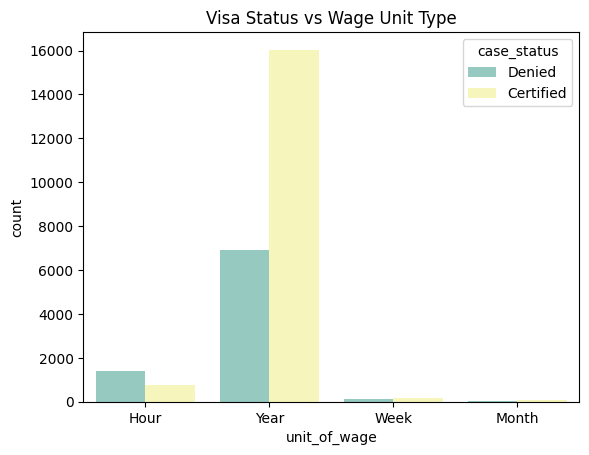

In [ ]:
# unit_of_wage vs case_status

sns.countplot(x='unit_of_wage', hue='case_status', data=df, palette='Set3')
plt.title("Visa Status vs Wage Unit Type")
plt.show()

## Observations/Conclusions:

* Most visa applications are reported with yearly wages, followed by hourly.

* Applications with yearly wage units show higher certification success compared to hourly or weekly wages.

* Indicates that higher, stable salary structures are preferred for certification.

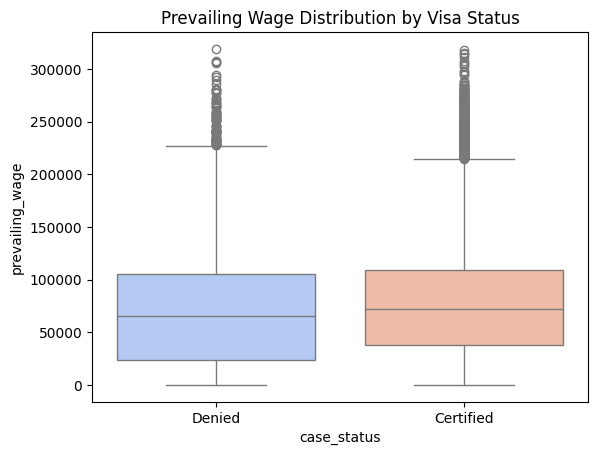

In [ ]:
# prevailing_wage vs case_status

sns.boxplot(x='case_status', y='prevailing_wage', data=df, palette='coolwarm')
plt.title("Prevailing Wage Distribution by Visa Status")
plt.show()

## Observations/Conclusions:

* Certified applicants have higher median prevailing wages compared to denied ones.

* There are several high-wage outliers among certified cases, possibly senior or specialized roles.

* This confirms that higher wages are positively correlated with visa approvals.

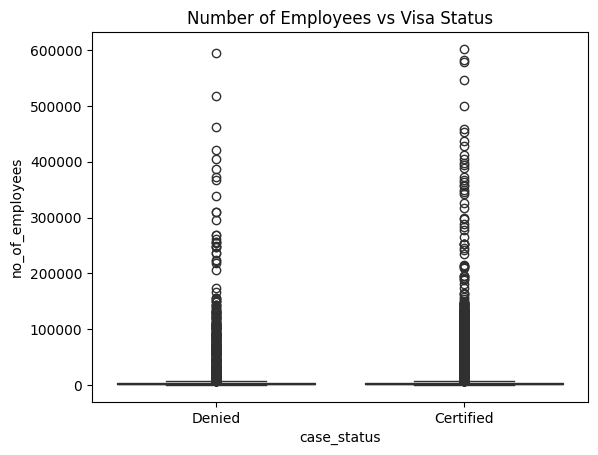

In [ ]:
# no_of_employees vs case_status

sns.boxplot(x='case_status', y='no_of_employees', data=df, palette='magma')
plt.title("Number of Employees vs Visa Status")
plt.show()

## Observations/Conclusions:

* Companies with a larger number of employees tend to have higher visa approval rates.

* Smaller firms show greater variability and more denials.

* Suggests that established or large organizations have a better chance of getting approvals.

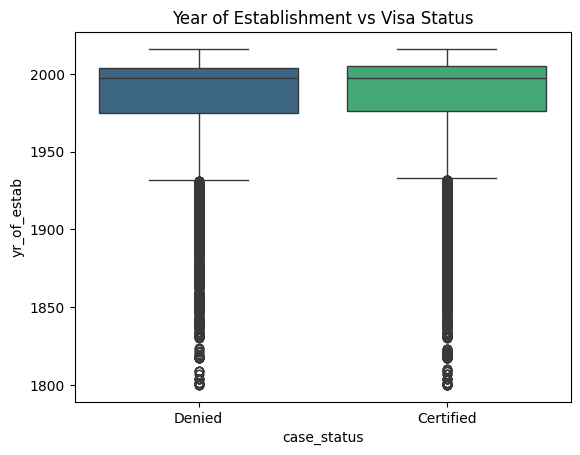

In [ ]:
# yr_of_estab vs case_status

sns.boxplot(x='case_status', y='yr_of_estab', data=df, palette='viridis')
plt.title("Year of Establishment vs Visa Status")
plt.show()

## Observations/Conclusions:

* Companies established in recent decades (post-1980) have more visa applications and a higher share of certifications.

* Very old firms (pre-1950) and very new firms show less consistency in approval rates.

* Indicates that mid-aged, stable firms are most successful in visa sponsorship.

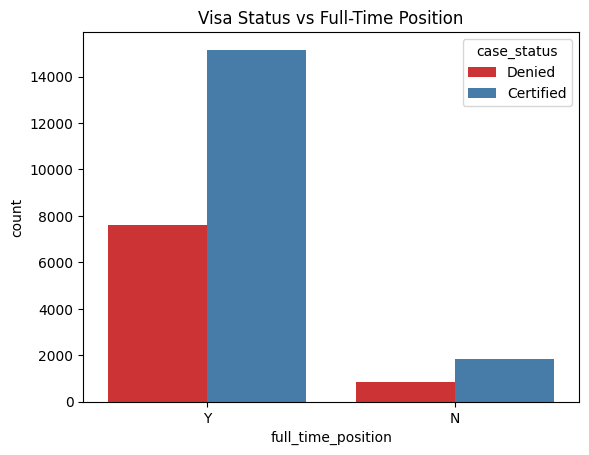

In [ ]:
# full_time_position vs case_status

sns.countplot(x='full_time_position', hue='case_status', data=df, palette='Set1')
plt.title("Visa Status vs Full-Time Position")
plt.show()

## Observations/Conclusions:
* Full-time positions dominate certified cases, while part-time roles have a higher proportion of denials.

* This clearly shows that full-time employment status increases the likelihood of visa certification.

## EDA Conclusions

* The dataset contains 25,480 visa applications with 11 variables (8 categorical, 3 numerical).

* It includes applicant details (education, experience), employer details (region, company size, year of establishment), and job characteristics (wage, employment type, full-time status).

* The target variable is case_status — whether a visa application was Certified or Denied.


* revailing_wage, has_job_experience, and education_of_employee show positive correlation with visa approval.

* requires_job_training and low wage levels show negative correlation.

* Numeric correlation among features (employees, year, wage) is moderate, indicating each adds unique value.

* The visa approval process favors highly educated, experienced applicants with higher wages and stable (full-time, long-term) employment offers.

* Regional and wage variations strongly influence approval chances.

* Outlier handling — a few companies had extremely high employee counts and wages.

* The dataset is slightly imbalanced (≈2:1 Certified:Denied) but suitable for predictive modeling.

* Features like education level, experience, full-time status, and wage are likely to be the strongest predictors for visa certification outcomes.

**Data Cleaning**
* Dropped "case_id" as "case_id" is unique for each candidate and might not add value to modeling.
* All columns have equal number of non-null values(25480) - indicates there are no missing values.
* There are no duplicates in the dataset.


## Data Pre-processing

### Outlier Check

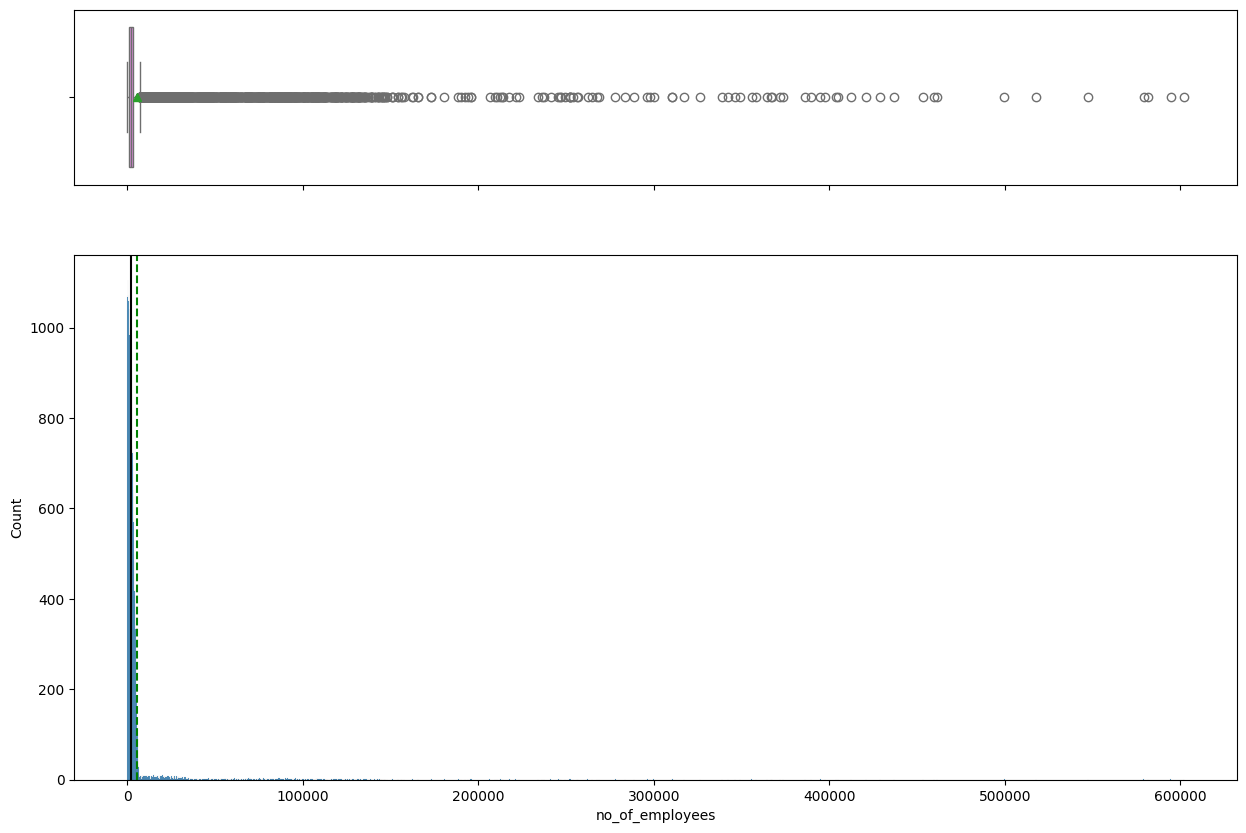

In [ ]:
# Outliers were primarily present in no_of_employees, prevailing_wage and yr_of_estab columns.
histogram_boxplot(df, "no_of_employees")

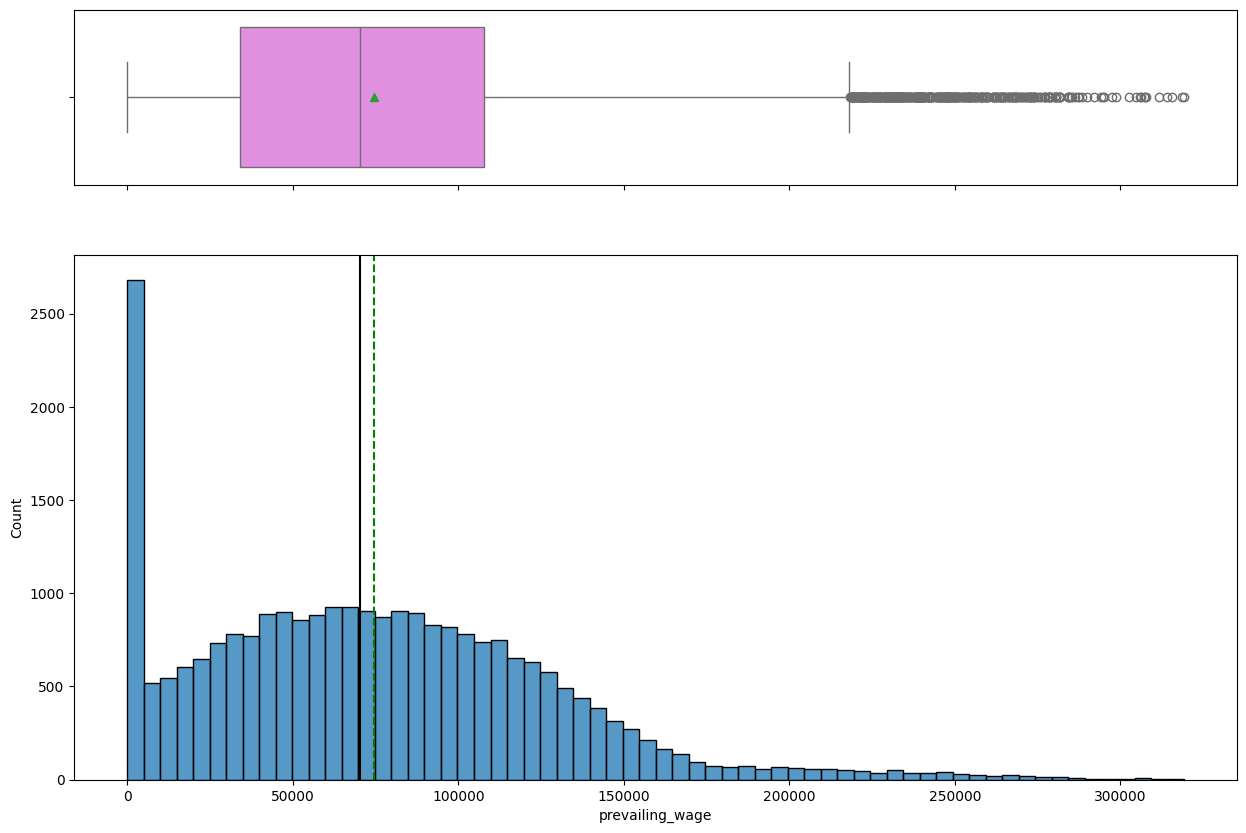

In [ ]:
# Outliers were primarily present in no_of_employees, prevailing_wage and yr_of_estab columns.
histogram_boxplot(df, "prevailing_wage")

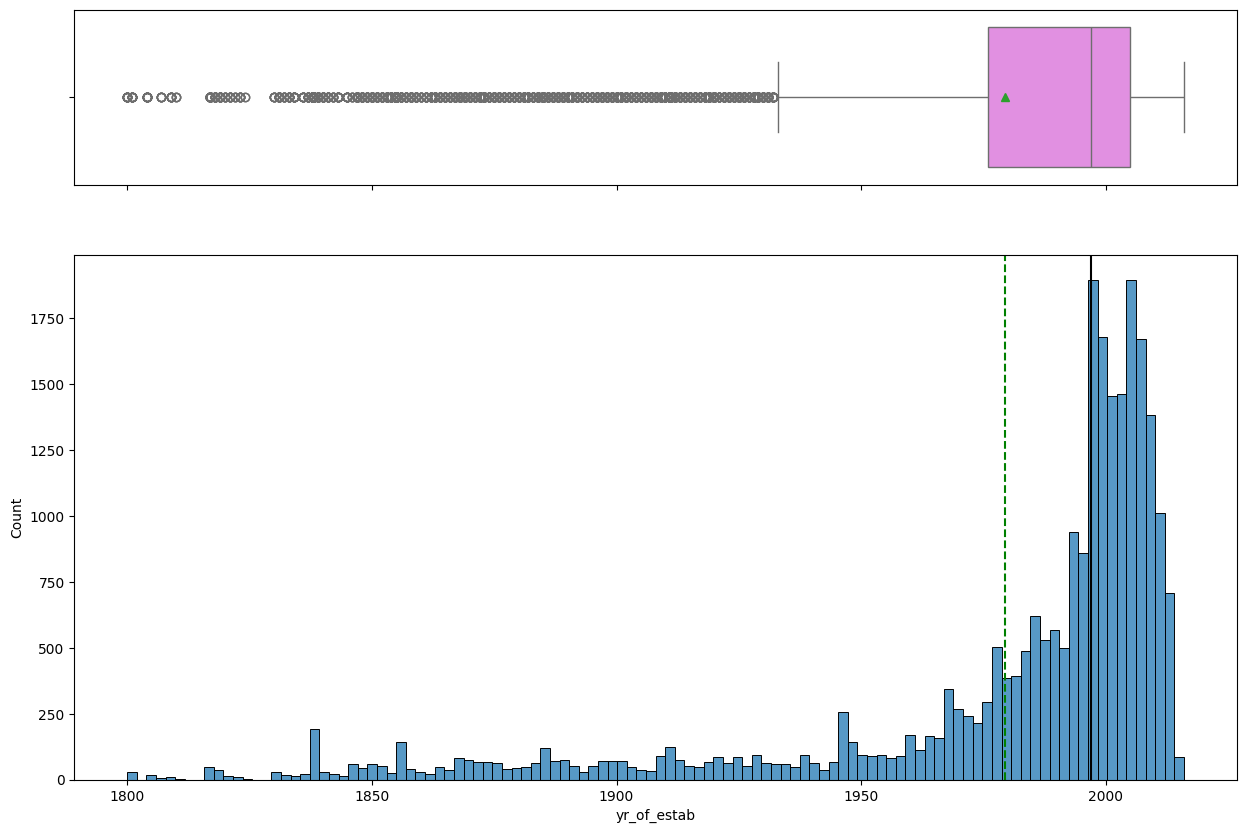

In [ ]:
# Outliers were primarily present in no_of_employees, prevailing_wage and yr_of_estab columns.
histogram_boxplot(df, "yr_of_estab")

### Observations

* Outliers were primarily observed in no_of_employees, prevailing_wage and yr_of_estab columns.
* Negative values in no_of_employees were converted to their absolute values.
* One of the employer had upto 602069 employees indicating a large organization, likely an outlier compared to other majority of employers in the given dataset. But this seems to be a valid entry as there are a few large organizations such as TCS(Tata Consulting Services), in the world with this kind of workforce and applying for huge number of visa applications. So, no need to treat these outliers as they seem to be valid.
* The prevailing_wage boxplot shows several high-value outliers, indicating a few specialized or executive-level jobs with unusually high salaries. These are valid job positions with valid wage levels. So, no need to treat them.
* The boxplot for yr_of_estab shows many outliers on the lower end (before 1900), indicating legacy or historically extablished companies still operating. Hence, no need to treat them.


## Feature Engineering

In [ ]:
data1 = df.copy()

In [ ]:
# we need to pass numerical values for each categorical column for imputation so we will label encode them
#  0   continent              25480 non-null  object D
#  1   education_of_employee  25480 non-null  object D
#  2   has_job_experience     25480 non-null  object D
#  3   requires_job_training  25480 non-null  object D
#  4   no_of_employees        25480 non-null  int64
#  5   yr_of_estab            25480 non-null  int64
#  6   region_of_employment   25480 non-null  object D
#  7   prevailing_wage        25480 non-null  float64EasyVisa_Full_Code_Notebook.ipynb
#  8   unit_of_wage           25480 non-null  object D
#  9   full_time_position     25480 non-null  object D
#  10  case_status            25480 non-null  object D


# One-hot encoding for nominal columns
# nominal_cols = ['continent', 'region_of_employment', 'unit_of_wage'] -->> One-hot encoding TO BE DONE after train, validation & test split

# Ordinal encoding for education level since we know the natural order
edu_order = {'High School': 0, "Bachelor's": 1, "Master's": 2, "Doctorate": 3}
data1['education_of_employee'] = data1['education_of_employee'].map(edu_order)

# Binary columns
binary_cols = ['has_job_experience', 'requires_job_training', 'full_time_position']
for col in binary_cols:
    data1[col] = data1[col].map({'Y': 1, 'N': 0})


In [ ]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
data1.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,0,0,0,14513,2007,West,592.203,Hour,1,Denied
1,Asia,2,1,0,2412,2002,Northeast,83425.650,Year,1,Certified
2,Asia,1,0,1,44444,2008,West,122996.860,Year,1,Denied
3,Asia,1,0,0,98,1897,West,83434.030,Year,1,Denied
4,Africa,2,1,0,1082,2005,South,149907.390,Year,1,Certified


* Values have been encoded.
* One-hot encoding for the nominal columns - ['continent', 'region_of_employment', 'unit_of_wage'] TO BE DONE after train, validation & test split

# Data Preparation for Modeling

In [ ]:
X = data1.drop(["case_status"], axis=1)
y = data1["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

In [ ]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


## Missing Value/Duplicates Treatment

In [ ]:
data1.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


* All columns have equal number of non-null values - indicates there are no missing values.
* There are no duplicates in the dataset.
* Hence data imputation is not required.

In [ ]:
# Checking that no column has missing values in train, validation or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
dtype: int64


## Creating Dummy Variables

In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_train = X_train.astype(float)

X_val = pd.get_dummies(X_val, drop_first=True)
X_val = X_val.astype(float)

X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.astype(float)

print(X_train.shape, X_val.shape, X_test.shape)

(15288, 19) (5096, 19) (5096, 19)


* After encoding, there are 19 columns

In [ ]:
X_train.head()

,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
5008,1.000,1.000,0.000,1020.000,2008.000,70919.850,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000
12951,2.000,1.000,1.000,1624.000,2003.000,59082.940,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000
3214,1.000,0.000,0.000,438.000,1991.000,22235.800,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000
18876,1.000,0.000,0.000,211.000,1911.000,18937.370,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
21939,1.000,0.000,0.000,2696.000,2007.000,65906.820,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000


In [ ]:
y_train.head()

,case_status
5008,0
12951,1
3214,0
18876,1
21939,1


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

## Primary Metric: Recall

* Recall measures how many of the actual “Certified” cases the model correctly identifies.

* A high Recall means the model captures most of the real visa approvals (Certified), even if it occasionally includes some false positives.

* Missing a truly qualified applicant (a false negative) is more costly than mistakenly shortlisting a few denied ones (a false positive).

Business reasoning:

* OFLC wants to automate the shortlist for likely approvals.

* It's okay if the shortlist includes some false approvals — they can be manually reviewed.

* But missing genuine eligible applicants defeats the purpose of automation. Therefore, maximizing Recall is the right goal.

* Hence chose Recall as the primary metric for the model evaluation.


First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

* OFLC wants to automate the shortlist for likely approvals.

* It's okay if the shortlist includes some false approvals — they can be manually reviewed.

* But missing genuine eligible applicants defeats the purpose of automation. Therefore, maximizing Recall is the right goal.

* Hence chose Recall as the primary metric for the model evaluation.

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9877571008814887
Random forest: 1.0
GBM: 0.8802154750244858
Adaboost: 0.8874632713026445
dtree: 1.0

Validation Performance:

Bagging: 0.7779083431257344
Random forest: 0.8416568742655699
GBM: 0.8766157461809636
Adaboost: 0.8804347826086957
dtree: 0.7567567567567568


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9878, Validation Score: 0.7779, Difference: 0.2098
Random forest: Training Score: 1.0000, Validation Score: 0.8417, Difference: 0.1583
GBM: Training Score: 0.8802, Validation Score: 0.8766, Difference: 0.0036
Adaboost: Training Score: 0.8875, Validation Score: 0.8804, Difference: 0.0070
dtree: Training Score: 1.0000, Validation Score: 0.7568, Difference: 0.2432


- Adaboost(Training Score: 0.8875, Validation Score: 0.8804) has the best performance followed by GBM(Training Score: 0.8802, Validation Score: 0.8766) model as per the validation performance

### Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 19)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9847208619000979
Random forest: 0.9999020568070519
GBM: 0.8657198824681684
Adaboost: 0.8573947110675808
dtree: 1.0

Validation Performance:

Bagging: 0.7714453584018801
Random forest: 0.831668625146886
GBM: 0.8586956521739131
Adaboost: 0.8519388954171563
dtree: 0.7414806110458284


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9847, Validation Score: 0.7714, Difference: 0.2133
Random forest: Training Score: 0.9999, Validation Score: 0.8317, Difference: 0.1682
GBM: Training Score: 0.8657, Validation Score: 0.8587, Difference: 0.0070
Adaboost: Training Score: 0.8574, Validation Score: 0.8519, Difference: 0.0055
dtree: Training Score: 1.0000, Validation Score: 0.7415, Difference: 0.2585


- GBM(Training Score: 0.8657, Validation Score: 0.8587) has the best performance followed by Adaboost(Training Score: 0.8574, Validation Score: 0.8519) model as per the validation performance

### Model Building with Undersampled data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 19)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.967703820401733
Random forest: 1.0
GBM: 0.7518708152816069
Adaboost: 0.7120913745569122
dtree: 1.0

Validation Performance:

Bagging: 0.6157461809635723
Random forest: 0.6706815511163338
GBM: 0.7353113983548766
Adaboost: 0.7112220916568742
dtree: 0.6321974148061105


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9677, Validation Score: 0.6157, Difference: 0.3520
Random forest: Training Score: 1.0000, Validation Score: 0.6707, Difference: 0.3293
GBM: Training Score: 0.7519, Validation Score: 0.7353, Difference: 0.0166
Adaboost: Training Score: 0.7121, Validation Score: 0.7112, Difference: 0.0009
dtree: Training Score: 1.0000, Validation Score: 0.6322, Difference: 0.3678


Here too, GBM has the best performance on validation compared to other models, followed by Adaboost.

# Performance Comparisions

# Performance on Original Data
Training and Validation Performance Difference:

* Bagging: Training Score: 0.9878, Validation Score: 0.7779, Difference: 0.2098
* Random forest: Training Score: 1.0000, Validation Score: 0.8417, Difference: 0.1583
* **GBM: Training Score: 0.8802, Validation Score: 0.8766, Difference: 0.0036**
* **Adaboost: Training Score: 0.8875, Validation Score: 0.8804, Difference: 0.0070**
* dtree: Training Score: 1.0000, Validation Score: 0.7568, Difference: 0.2432

# Performance on OverSampled Data

Training and Validation Performance Difference:

* Bagging: Training Score: 0.9847, Validation Score: 0.7714, Difference: 0.2133
* Random forest: Training Score: 0.9999, Validation Score: 0.8317, Difference: 0.1682
* **GBM: Training Score: 0.8657, Validation Score: 0.8587, Difference: 0.0070**
* **Adaboost: Training Score: 0.8574, Validation Score: 0.8519, Difference: 0.0055**
* dtree: Training Score: 1.0000, Validation Score: 0.7415, Difference: 0.2585



# Performance on UnderSampled Data
Training and Validation Performance Difference:

* Bagging: Training Score: 0.9677, Validation Score: 0.6157, Difference: 0.3520
* Random forest: Training Score: 1.0000, Validation Score: 0.6707, Difference: 0.3293
* **GBM: Training Score: 0.7519, Validation Score: 0.7353, Difference: 0.0166**
* **Adaboost: Training Score: 0.7121, Validation Score: 0.7112, Difference: 0.0009**
* dtree: Training Score: 1.0000, Validation Score: 0.6322, Difference: 0.3678


# Final Conclusions:

* Based on the above comparision of performances on Original vs OverSampled vs UnderSampled data, we can conclude below as top 3 performing models that can be tuned further to decide the final best model.

  **Top 3 Models, based on performance on Validation:**

1. **Adaboost: Training Score: 0.8875, Validation Score: 0.8804, Difference: 0.0070** - (from Original Dataset)
2. **GBM: Training Score: 0.8802, Validation Score: 0.8766, Difference: 0.0036** - (from Original Data)
3. **GBM: Training Score: 0.8657, Validation Score: 0.8587, Difference: 0.0070** - (from OverSampled Dataset)

* We will tune these 3 models using the same data (original or oversampled) as we trained them on before


## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

# Tuning AdaboostClassifier model with Original Dataset

1 **Adaboost: Training Score: 0.8875, Validation Score: 0.8804, Difference: 0.0070** - (from Original Dataset)

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(20), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=1.0:
CPU times: user 1.56 s, sys: 274 ms, total: 1.83 s
Wall time: 1min 16s


* Best parameters are {'n_estimators': np.int64(20), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=1.0:
CPU times: user 1.56 s, sys: 274 ms, total: 1.83 s
Wall time: 1min 16s

In [ ]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.01,
    estimator=DecisionTreeClassifier(max_depth=1, random_state=1),
)
tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.01, n_estimators=20, random_state=1)

In [ ]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


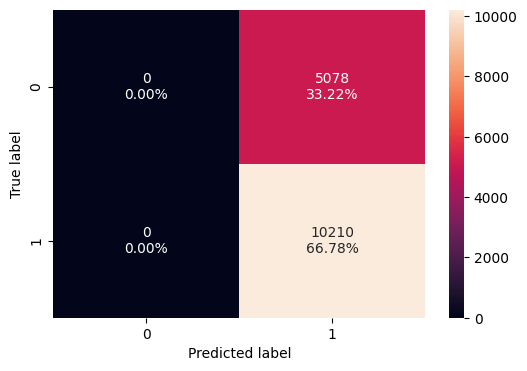

In [ ]:
adb_train_confusion_matrix = confusion_matrix_sklearn(tuned_adb, X_train, y_train)
adb_train_confusion_matrix

In [ ]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


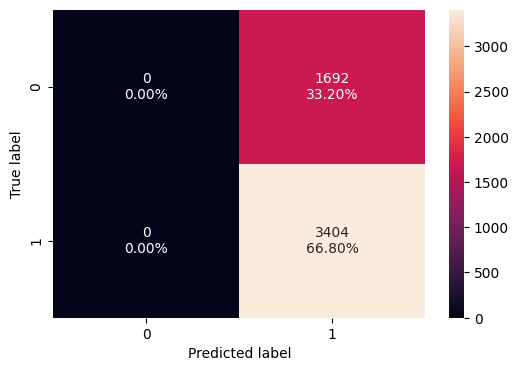

In [ ]:
adb_val_confusion_matrix = confusion_matrix_sklearn(tuned_adb, X_val, y_val)
adb_val_confusion_matrix

# Observations

* We can see that the recall scores for both training and validation are 1, indicating that this model has successfully identified all actual Certified(approved) visa cases.
* But, a Precision of only 66.8% indicates that even though 66.8% cases are certified, remaining 33.2% cases the model is incorrectly identifying denied cases as Certified.
* This indicates the model is highly biased towards the Certified class or is oversimplied.

# Tuning Gradient Boosting model with Original Data

2. **GBM: Training Score: 0.8802, Validation Score: 0.8766, Difference: 0.0036** - (from Original Data)

In [ ]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': np.int64(150), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.9386875612144957:
CPU times: user 3.78 s, sys: 560 ms, total: 4.34 s
Wall time: 6min 23s


* Best parameters are {'subsample': 1, 'n_estimators': np.int64(150), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.9386875612144957:
CPU times: user 3.78 s, sys: 560 ms, total: 4.34 s
Wall time: 6min 23s

In [ ]:
# Tuning with the best parameters obtained from above step
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=150,
    max_features=1,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1, n_estimators=150,
                           random_state=1, subsample=1)

In [ ]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train, y_train
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.722,0.939,0.725,0.819


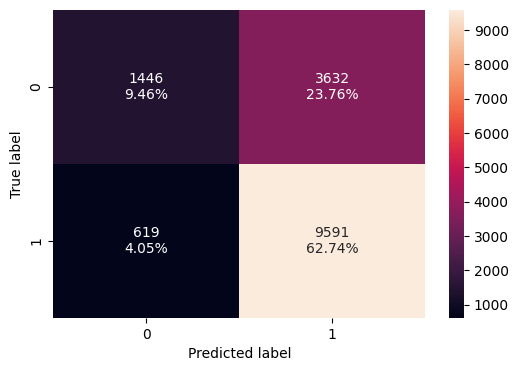

In [ ]:
gbm1_train_confusion_matrix = confusion_matrix_sklearn(tuned_gbm1, X_train, y_train)
gbm1_train_confusion_matrix

In [ ]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.724,0.936,0.728,0.819


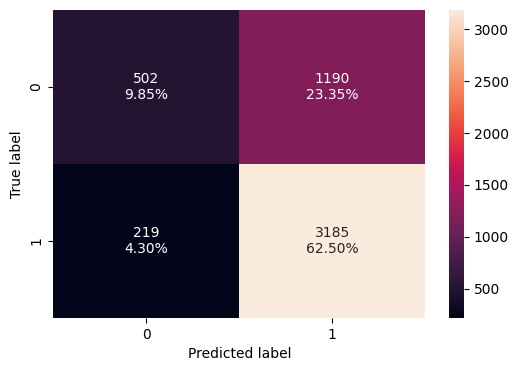

In [ ]:
gbm1_val_confusion_matrix = confusion_matrix_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val_confusion_matrix

# Observations

* We can see that the recall scores on both the traning set(0.939) and validation set(0.936) are almost identical. This is indicates the model is not overfitting and has excellent generaliation ability.

* The high Recall value (0.936) confirms that the model successfully identifies most of the actual Certified visa cases — aligning with the project goal of maximizing Recall.

* And F1, Precision and Accuracy values are also very close between training & validation.

* Overall tuned GBM model demonstrates strong and stable performance across training and validation sets.

* The confusion matrix accurately reflects the model's performance metrics — the counts of true positives, false positives, true negatives, and false negatives are consistent with the calculated Accuracy, Precision, Recall, and F1-Score values shown above.

# Tuning Gradient Boosting model with OverSampled data
3. **GBM: Training Score: 0.8657, Validation Score: 0.8587, Difference: 0.0070** - (from OverSampled Dataset)

In [ ]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(125), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8748285994123408:
CPU times: user 5.35 s, sys: 628 ms, total: 5.98 s
Wall time: 7min 29s


* Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(125), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8748285994123408:
CPU times: user 5.35 s, sys: 628 ms, total: 5.98 s
Wall time: 7min 29s

In [ ]:
tuned_gbm2 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.5,
    n_estimators=125,
    max_features=1,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.5)

In [ ]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(tuned_gbm2, X_train_over, y_train_over)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.793,0.884,0.749,0.811


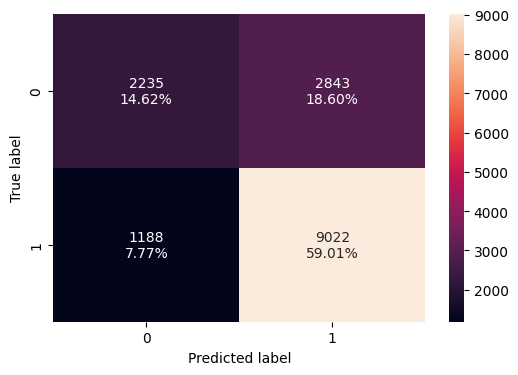

In [ ]:
gbm2_train_confusion_matrix = confusion_matrix_sklearn(tuned_gbm2, X_train, y_train)
gbm2_train_confusion_matrix

In [ ]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(tuned_gbm2, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.736,0.878,0.762,0.816


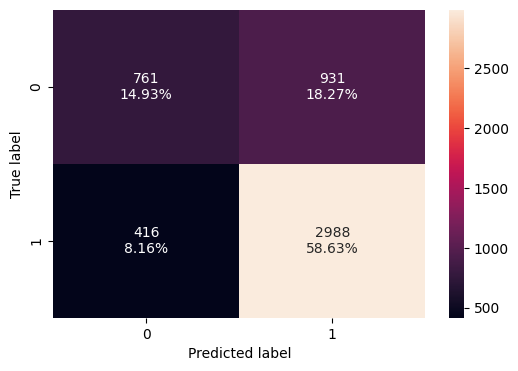

In [ ]:
gbm2_val_confusion_matrix = confusion_matrix_sklearn(tuned_gbm2, X_val, y_val)
gbm2_val_confusion_matrix

# Observations

* We can see that the recall scores on both the traning set(0.884) and validation set(0.878) are almost identical. This is indicates the model is not overfitting and has excellent generaliation ability.

* The high Recall value (0.878) confirms that the model successfully identifies most of the actual Certified visa cases — aligning with the project goal of maximizing Recall.

* And F1, Precision and Recall values are also very close between training & validation.

* Overall tuned GBM model demonstrates strong and stable performance across training and validation sets.

* But the tuned GBM model on Original Dataset has better performance metrics(Higher recall) than this GBM model on Oversampled data.

* The confusion matrix accurately reflects the model's performance metrics — the counts of true positives, false positives, true negatives, and false negatives are consistent with the calculated Accuracy, Precision, Recall, and F1-Score values shown above.

## Model Performance Summary and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        adb_train.T,
        gbm1_train.T,
        gbm2_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost trained with Original data",
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost trained with Original data,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data
Accuracy,0.668,0.722,0.793
Recall,1.000,0.939,0.884
Precision,0.668,0.725,0.749
F1,0.801,0.819,0.811


In [ ]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ adb_val.T, gbm1_val.T, gbm2_val.T ], axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost trained with Original data",
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,AdaBoost trained with Original data,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data
Accuracy,0.668,0.724,0.736
Recall,1.000,0.936,0.878
Precision,0.668,0.728,0.762
F1,0.801,0.819,0.816


# Final Conclusion:

* We can see that after hypertuning the top 3 chosen models, the tuned GBM with the Original Dataset has the best(highest) recall scores for both training(0.939) and vaidation sets(0.936).

* This is indicates this model(tuned GBM with the Original Dataset) is not overfitting and has excellent generaliation ability.

* The high Recall value (0.936) confirms that the model successfully identifies most of the actual Certified visa cases — aligning with the project goal of maximizing Recall.

* And F1, Precision and Recall values are also very close between training & validation.

* Overall, this tuned GBM(tuned_gbm1) model demonstrates strong and stable performance across training and validation sets.

* So, let's consider this as the (tuned_gbm1) best model and check it's performance on the test dataset.

In [ ]:
# Let's check the performance on test set
gbm1_test = model_performance_classification_sklearn(tuned_gbm1, X_test, y_test)
gbm1_test

,Accuracy,Recall,Precision,F1
0,0.712,0.934,0.719,0.813


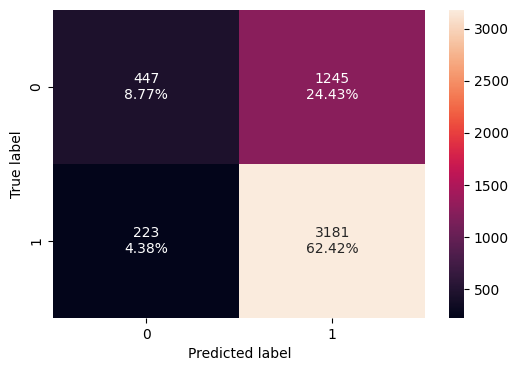

In [ ]:
gbm1_test_confusion_matrix = confusion_matrix_sklearn(tuned_gbm1, X_test, y_test)
gbm1_test_confusion_matrix

- The Gradient boosting model trained on original data has given 93.4% recall score on the test set.
- This performance is in line with what we achieved with this model on the train(93.9) and validation(93.6) sets
- So, this is a generalized model and is picked as the Final Model to go with.
- The confusion matrix accurately reflects the model's performance metrics — the counts of true positives, false positives, true negatives, and false negatives are consistent with the calculated Accuracy, Precision, Recall, and F1-Score values shown above.

# Feature Importance

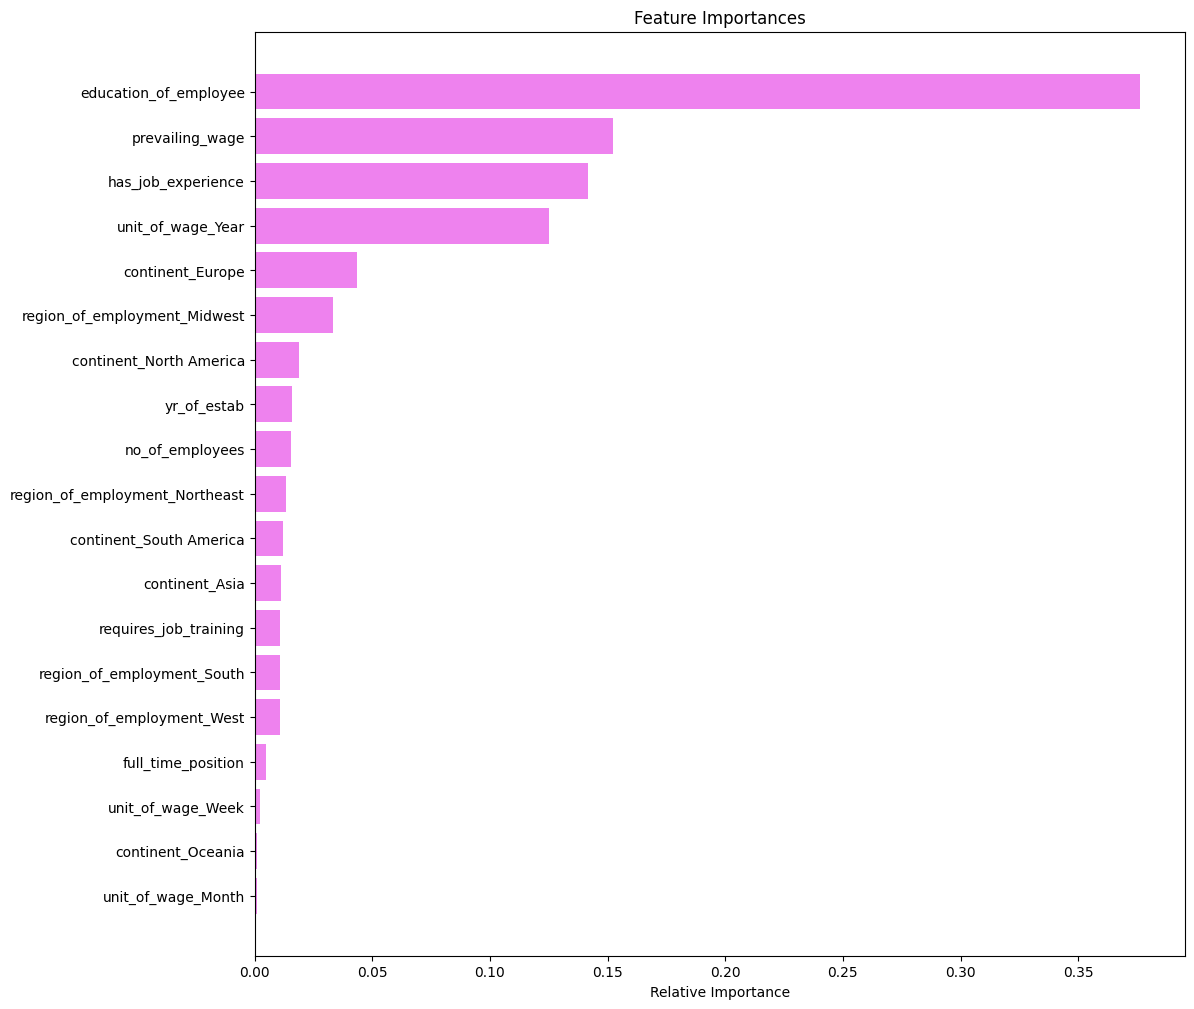

In [ ]:
feature_names = X_train.columns
importances = tuned_gbm1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Observations & Conclusions - Feature Importance (GBM Model)

* The GBM model's feature importance plot highlights which factors have the strongest influence on visa application outcomes (Certified vs Denied).

* The GBM model reveals that employee qualifications (education and experience) and wage offered (prevailing wage) are the top 3 primary determinants influencing visa certification decisions.

* The Unit of Wage (Yearly) and Continent (Europe, North America) also show moderate influence — applicants from these regions or those offered annual salary packages are more likely to receive visa certification.

* Features like Year of Establishment and Number of Employees have minor but noticeable importance, indicating that larger or older companies may have a slightly better success rate.

* Variables such as Region of Employment (South, West, etc.), Full-time Position, and Requires Job Training have relatively lower importance, implying limited effect on visa decision outcomes.

# Business Insights and Recommendations

* Insights:
  * From a business standpoint, the analysis shows that education level, prevailing wage, and prior job experience are the strongest drivers of visa approval.

  * The model's high Recall (≈ 0.94) indicates that it can successfully identify nearly all visa cases that are likely to be approved — minimizing the risk of missing eligible candidates.

  * This aligns with the project's goal of helping OFLC efficiently shortlist high-potential applicants without overlooking qualified profiles.

  * Employers offering competitive salaries and hiring highly educated, experienced professionals remain the most likely to secure visa certifications.

  * Large or established organizations also show a slightly higher approval rate, reflecting better compliance and credibility.

  * Less influential factors such as region of employment, job training requirement, and unit of wage type suggest that visa approvals are primarily merit-driven, not location- or format-dependent.

* Recommendation for EasyVisa & OFLC:
  * To streamline visa screening, EasyVisa can develop a data-driven scoring model that assigns higher priority to applications with strong educational backgrounds, substantial prior experience, and competitive wages.
  
  * This will help OFLC efficiently focus on high-likelihood approval cases, reducing manual workload while maintaining fairness and transparency in the certification process.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/ColabNotebooks/Advanced Machine Learning/Project-EasyVisa/EasyVisa_Full_Code_Notebook.ipynb"

<font size=6 color='blue'>Power Ahead</font>
___